In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

Read the data

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Google_Play_Store_apps/archive/googleplaystore.csv")

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\USER\Downloads\googleplaystore.csv\googleplaystore.csv")

Columns :

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Shape :

In [5]:
print("num of columns: ", df.shape[1] ,"\n"
      "num of rows   : ", df.shape[0])

num of columns:  13 
num of rows   :  10841


In [6]:
#noor
df.info()       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
#noor
df.describe()    

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


Sample :

In [8]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


uniqe&freq:

In [9]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values Count": [df[col].nunique() for col in df.columns]
})

unique_summary.sort_values(by="Unique Values Count", ascending=False)

,Column,Unique Values Count
0,App,9660
3,Reviews,6002
11,Current Ver,2832
10,Last Updated,1378
4,Size,462
9,Genres,120
7,Price,93
2,Rating,40
1,Category,34
12,Android Ver,33


In [10]:
for col in df.columns:
    print("====================================")
    print("Column:", col)

    vc = df[col].value_counts().reset_index()
    vc.columns = [col, "count"]

    print(vc.head(20))
    print(vc.tail(20))

Column: App
                                                  App  count
0                                              ROBLOX      9
1   CBS Sports App - Scores, News, Stats & Watch Live      8
2                      Duolingo: Learn Languages Free      7
3                                    Candy Crush Saga      7
4                                         8 Ball Pool      7
5                                                ESPN      7
6                                          Bowmasters      6
7                                        Temple Run 2      6
8                                     Zombie Catchers      6
9   Bleacher Report: sports news, scores, & highli...      6
10                                         slither.io      6
11                                     Bubble Shooter      6
12                                     Subway Surfers      6
13   Sniper 3D Gun Shooter: Free Shooting Games - FPS      6
14                                               Nick      6
15          

column_name: discreption


App: The name of the mobile application in the dataset.\
Category: The general category the app belongs to such as game, education, or tools.\
Rating: The average user rating of the app on a scale from 1 to 5.\
Reviews: The total number of user reviews the app has received.\
Size: The storage size of the application on a device.\
Installs: The number of times the app has been downloaded or installed.\
Type: Indicates whether the app is free or paid.\
Price: The cost of the app, with free apps having a value of zero.\
Content Rating: The age group the app is suitable for, such as Everyone or Teen.\
Genres: The specific subcategories that describe the app in more detail.\
Last Updated: The most recent date when the app was updated.\
Current Ver: The current version number of the app available.\
Android Ver: The minimum Android version required to run the app.\

now based on the projrct/research question(What factors influence app ratings on the Google Play Store? ) we will do a feature selection :

1. simple handleing:\
  a. type problem\
  b. some smale cleanning to make the EDA more represintaionable ($,M,K,+)\
c. faild inputs

In [11]:
# Data types(befor)
print("\nData Types:\n", df.dtypes)


Data Types:
 App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


a & b

In [12]:
def clean_size(size):
    if isinstance(size, str):
        size = size.strip()

        if size.endswith('M'):
            return float(size.replace('M', '')) * 1_000_000

        elif size.endswith('k'):
            return float(size.replace('k', '')) * 1_000

        else:
            return None
    return None

df['Size'] = df['Size'].apply(clean_size)

In [13]:
df['Price'] = df['Price'].replace(r'[$]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [14]:
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace('[+,]', '', regex=True)
)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [15]:
import numpy as np

def clean_reviews(x):
    if isinstance(x, str):
        x = x.replace(',', '').strip()
        if 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        if 'K' in x or 'k' in x:
            return float(x.replace('K', '').replace('k', '')) * 1_000
    try:
        return float(x)
    except:
        return np.nan

df['Reviews'] = df['Reviews'].apply(clean_reviews)
df['Reviews'] = df['Reviews'].astype('Int64')

In [16]:
df['Category'] = df['Category'].astype('category')
df['Type'] = df['Type'].astype('category')

In [17]:
# Data types(after)
print("\nData Types:\n", df.dtypes)


Data Types:
 App                 object
Category          category
Rating             float64
Reviews              Int64
Size               float64
Installs           float64
Type              category
Price              float64
Content Rating      object
Genres              object
Last Updated        object
Current Ver         object
Android Ver         object
dtype: object


c. the faild inputs:

In [18]:
#type=0
df['Type'] = df['Type'].replace('0', np.nan)
df = df.dropna(subset=['Type'])

#installs=free
df['Installs'] = df['Installs'].replace('Free', np.nan)
df = df.dropna(subset=['Installs'])

#price= everyone :)
df['Price'] = df['Price'].replace('Everyone', np.nan)
df = df.dropna(subset=['Price'])

#rating(1.9!!)
df = df[(df['Rating'] >= 0) & (df['Rating'] <= 5)]

C:\Users\USER\AppData\Local\Temp\ipykernel_8356\1918100823.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Type'] = df['Type'].replace('0', np.nan)


In [19]:
#to make sure no faildinput still:

df['Installs'].unique()

array([1.e+04, 5.e+05, 5.e+06, 5.e+07, 1.e+05, 5.e+04, 1.e+06, 1.e+07,
       5.e+03, 1.e+08, 1.e+09, 1.e+03, 5.e+08, 1.e+02, 5.e+02, 1.e+01,
       5.e+00, 5.e+01, 1.e+00])

now>>> lets start a comleate EDA (after the small handeling) :

In [20]:
# Shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

# First rows
df.head()

Dataset Shape: (9366, 13)

Columns:
 Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Data Types:
 App                 object
Category          category
Rating             float64
Reviews              Int64
Size               float64
Installs           float64
Type              category
Price              float64
Content Rating      object
Genres              object
Last Updated        object
Current Ver         object
Android Ver         object
dtype: object


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


missing values:

In [21]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
missing

,Missing Count,Missing Percentage (%)
Size,1637,17.48
Current Ver,4,0.04
Android Ver,2,0.02


COMPLETE EDA...:

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DUPLICATES
Total duplicated rows: 474
NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Rating,9366.0,4.191757,0.515219,1.0,4.0,4.3,4.5,5.0
Reviews,9366.0,514049.836536,3144042.127009,1.0,186.25,5930.5,81532.75,78158306.0
Size,7729.0,22957606.870229,23445491.095319,8500.0,5300000.0,14000000.0,33000000.0,100000000.0
Installs,9366.0,17897443.72603,91238217.37717,1.0,10000.0,500000.0,5000000.0,1000000000.0
Price,9366.0,0.960928,15.816585,0.0,0.0,0.0,0.0,400.0


CATEGORICAL SUMMARY

Column: App
App
ROBLOX                                                9
CBS Sports App - Scores, News, Stats & Watch Live     8
Candy Crush Saga                                      7
ESPN                                                  7
8 Ball Pool                                           7
Duolingo: Learn Languages Free                        7
Bleacher Report: sports news, scores, & highlights    6
Bowmasters                                            6
Temple Run 2                                          6
Subway Surfers                                        6
Name: count, dtype: int64

Unique Values: 8196

Column: Category
Category
FAMILY             1747
GAME               1097
TOOLS               734
PRODUCTIVITY        351
MEDICAL             350
COMMUNICATION       328
FINANCE             323
SPORTS              319
PHOTOGRAPHY         317
PERSONALIZATION     314
Name: count, dtype: int64

Unique Values: 33

Column: Type
Type
Free    8719
Paid     647

,Skewness
Rating,-1.849695
Reviews,15.307855
Size,1.433736
Installs,8.888325
Price,24.402265



              Skewness Interpretation:
              0        = Normal Distribution
              > 0      = Right Skewed
              < 0      = Left Skewed
              > 1      = Highly Skewed
              


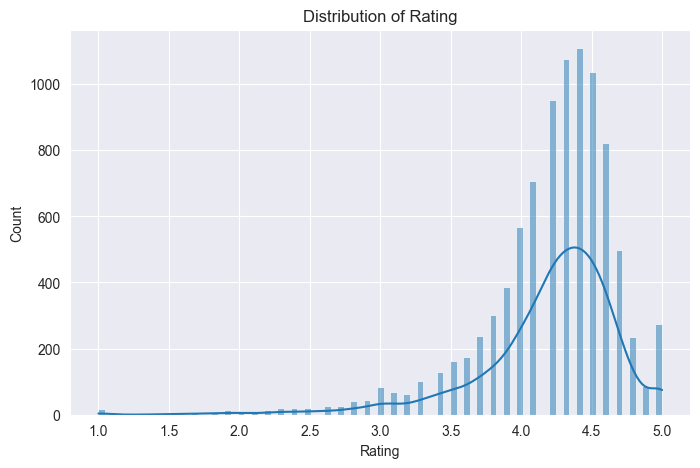

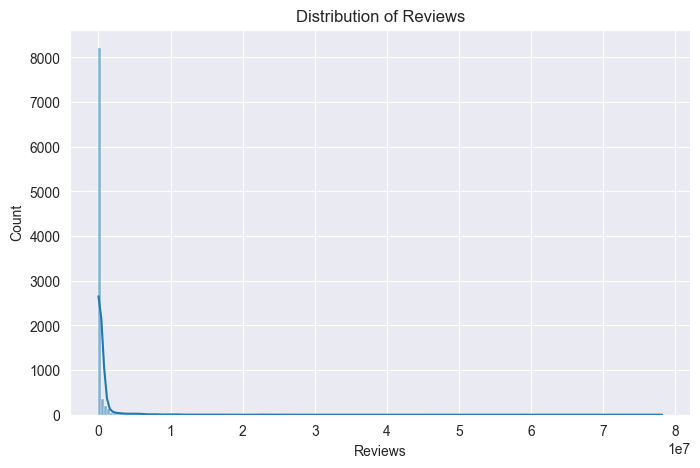

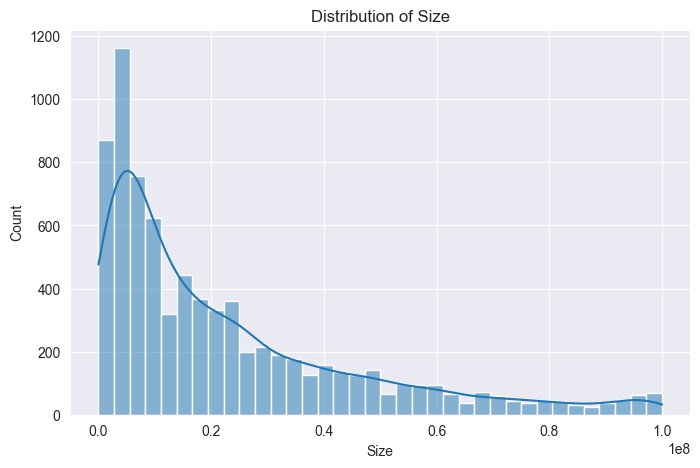

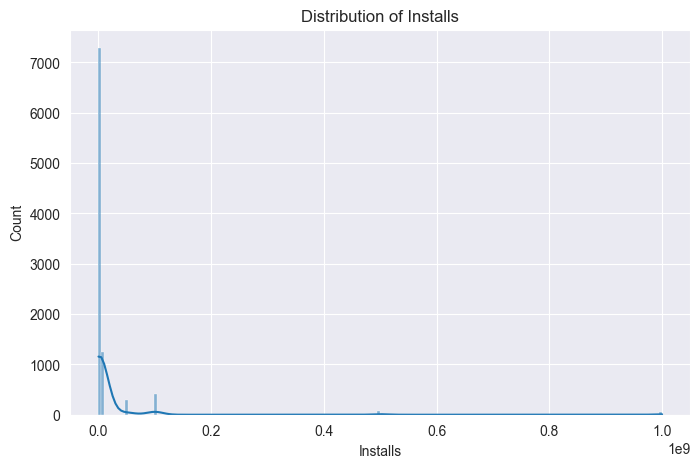

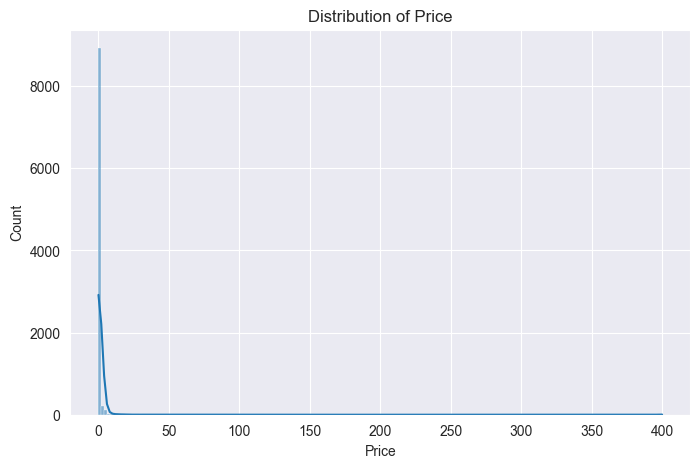


Column: Rating
Number of outliers: 503
     Rating
15      3.2
87      3.2
209     3.1
311     3.2
312     3.2
--------------------------------------------------

Column: Reviews
Number of outliers: 1634
     Reviews
3     215644
19    224399
42    295221
72    271920
139  2914724
--------------------------------------------------

Column: Size
Number of outliers: 412
           Size
600  77000000.0
695  77000000.0
728  84000000.0
748  97000000.0
790  76000000.0
--------------------------------------------------

Column: Installs
Number of outliers: 828
         Installs
3    5.000000e+07
139  1.000000e+08
143  1.000000e+08
152  1.000000e+09
188  5.000000e+07
--------------------------------------------------

Column: Price
Number of outliers: 647
     Price
234   4.99
235   4.99
290   4.99
291   4.99
427   3.99
--------------------------------------------------


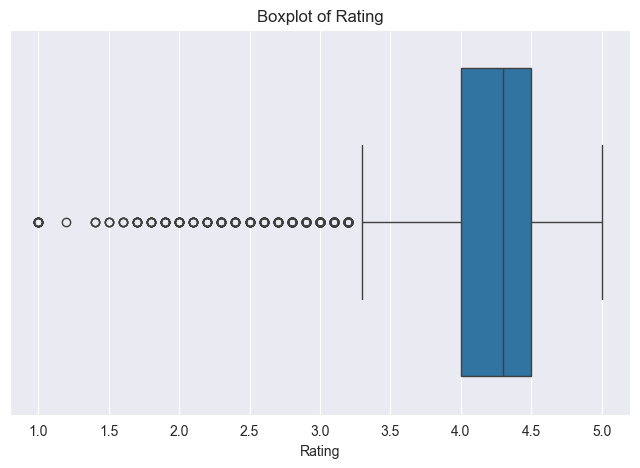

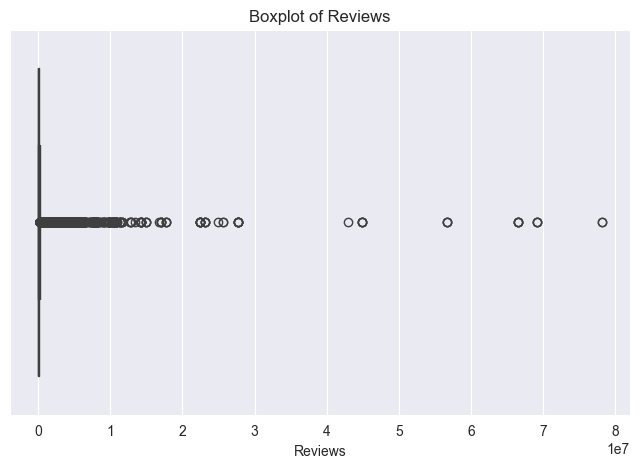

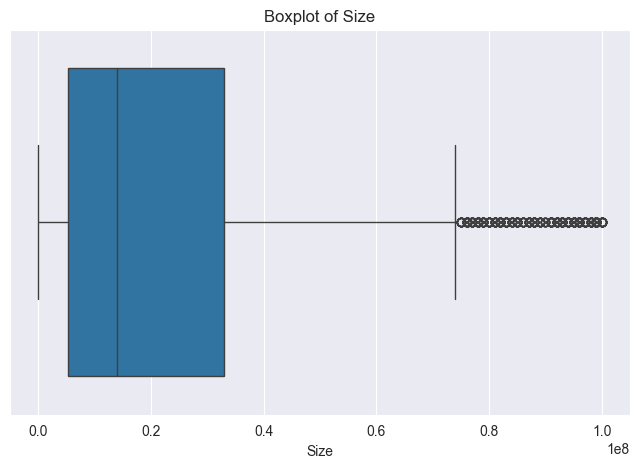

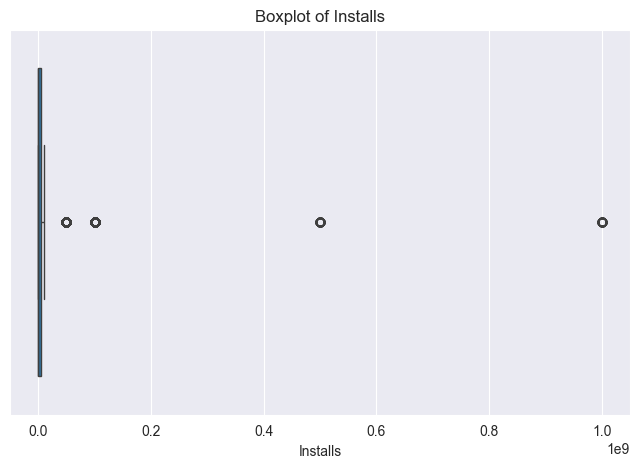

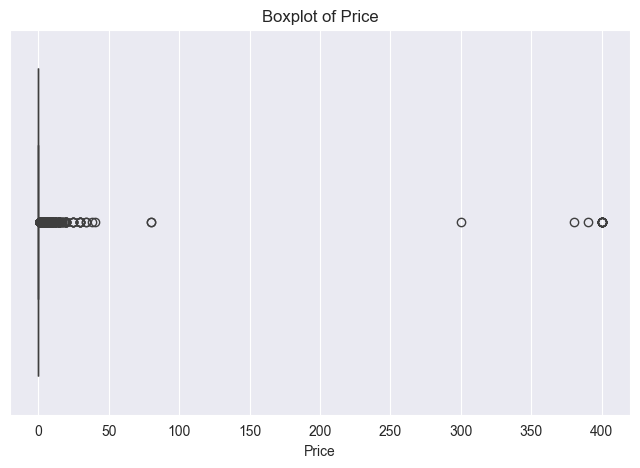

CORRELATION MATRIX


,Rating,Reviews,Size,Installs,Price
Rating,1.000000,0.068141,0.083734,0.051355,-0.021903
Reviews,0.068141,1.000000,0.240414,0.641612,-0.009820
Size,0.083734,0.240414,1.000000,0.162759,-0.026240
Installs,0.051355,0.641612,0.162759,1.000000,-0.011890
Price,-0.021903,-0.009820,-0.026240,-0.011890,1.000000


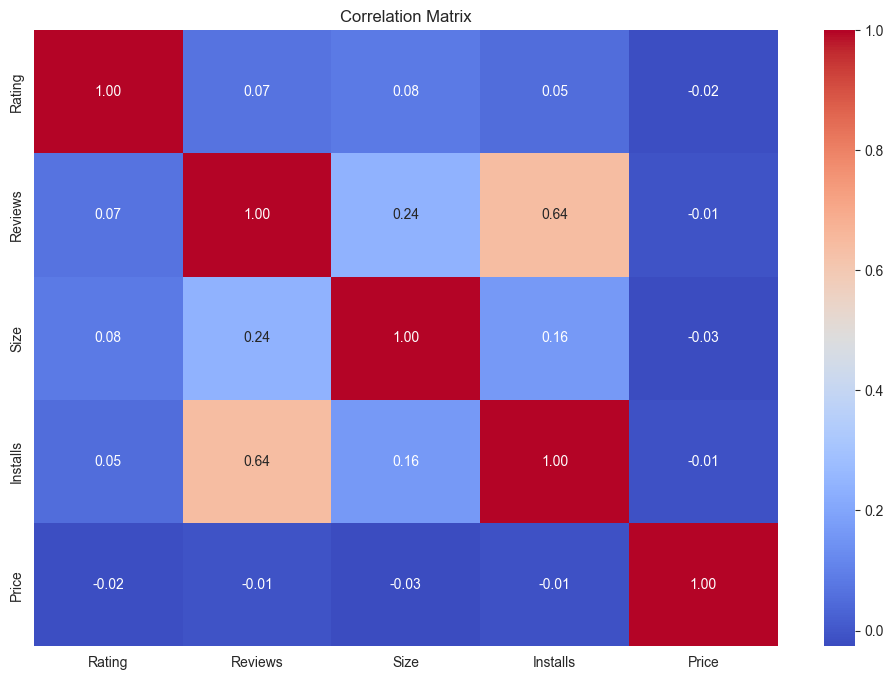

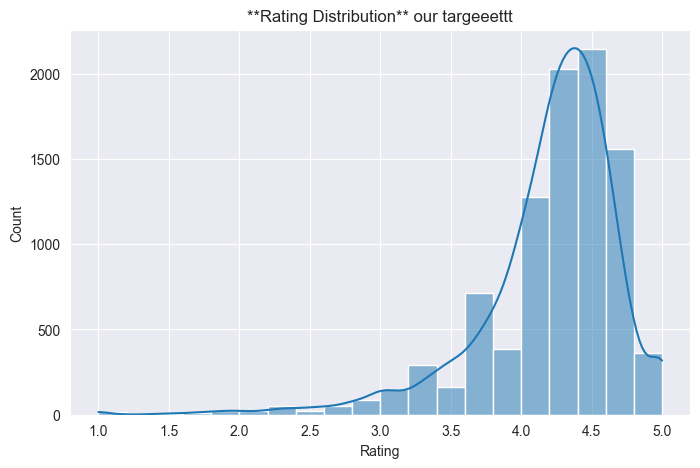

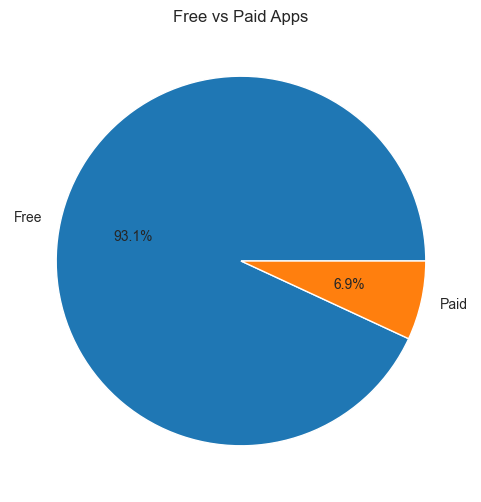

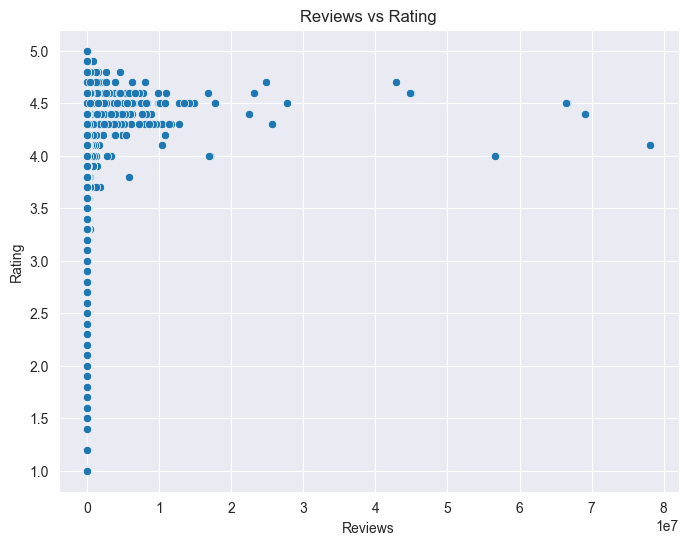

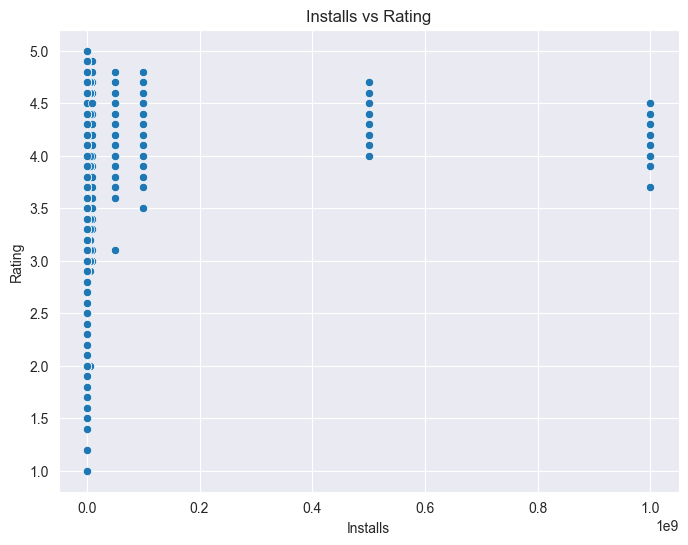

Number of paid apps: 647

Price Statistics:


count    647.000000
mean      13.910433
std       58.704314
min        0.990000
25%        1.990000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

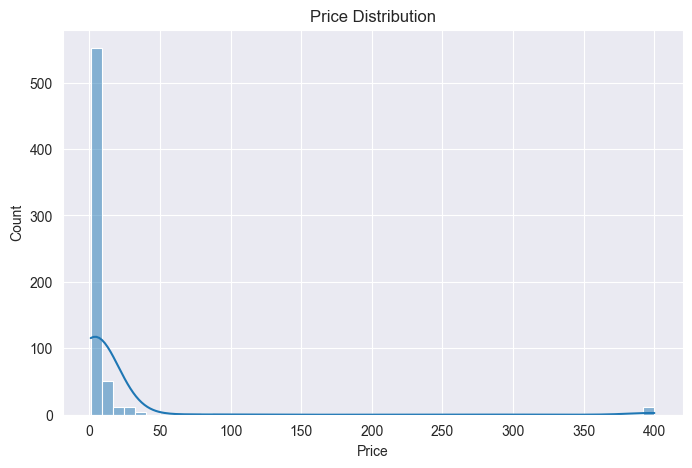

In [23]:
# Style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (15, 6)

# =========================================================
# CLASS: COMPLETE EDA
# =========================================================

class CompleteEDA:

    def __init__(self, df):
        self.df = df

    # =====================================================
    #  DUPLICATES
    # =====================================================
    def duplicates_info(self):

        print("=" * 60)
        print("DUPLICATES")
        print("=" * 60)

        total_duplicates = self.df.duplicated().sum()

        print("Total duplicated rows:",
              total_duplicates)



    # =====================================================
    #  NUMERICAL SUMMARY
    # =====================================================
    def numerical_summary(self):

        print("=" * 60)
        print("NUMERICAL SUMMARY")
        print("=" * 60)

        display(self.df.describe().T)



    # =====================================================
    #  CATEGORICAL SUMM
    # =====================================================
    def categorical_summary(self):

        print("=" * 60)
        print("CATEGORICAL SUMMARY")
        print("=" * 60)

        categorical_cols = self.df.select_dtypes(
            include=['object', 'category', 'string']
        ).columns

        for col in categorical_cols:

            print("\n" + "=" * 40)
            print(f"Column: {col}")
            print("=" * 40)

            print(self.df[col].value_counts().head(10))

            print("\nUnique Values:",
                  self.df[col].nunique())



    # =====================================================
    #   SKEWNESS
    # =====================================================
    def check_skewness(self):

        print("=" * 60)
        print("SKEWNESS")
        print("=" * 60)

        numerical_cols = self.df.select_dtypes(
            include=['int64', 'float64']
        ).columns

        skewness = self.df[numerical_cols].skew()

        skew_df = pd.DataFrame({
            'Skewness': skewness
        })

        display(skew_df)

        # Interpretation
        print("""
              Skewness Interpretation:
              0        = Normal Distribution
              > 0      = Right Skewed
              < 0      = Left Skewed
              > 1      = Highly Skewed
              """)


    # =====================================================
    #  HISTOGRAMS
    # =====================================================
    def histograms(self):

        numerical_cols = self.df.select_dtypes(
            include=['int64', 'float64']
        ).columns

        for col in numerical_cols:

            plt.figure(figsize=(8,5))

            sns.histplot(
                self.df[col],
                kde=True
            )

            plt.title(f"Distribution of {col}")

            plt.show()


    # =====================================================
    #  OUTLIERS
    #======================================================

    def detect_outliers_iqr(self):

        numerical_cols = self.df.select_dtypes(include=['int64', 'float64']).columns

        for col in numerical_cols:

            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = self.df[
                (self.df[col] < lower_bound) |
                (self.df[col] > upper_bound)
            ]

            print(f"\nColumn: {col}")
            print(f"Number of outliers: {len(outliers)}")

            if len(outliers) > 0:
                print(outliers[[col]].head())
                print("-" * 50)

    # =====================================================
    #  BOXPLOTS (OUTLIERS)
    # =====================================================
    def boxplots(self):

        numerical_cols = self.df.select_dtypes(
            include=['int64', 'float64']
        ).columns

        for col in numerical_cols:

            plt.figure(figsize=(8,5))

            sns.boxplot(
                x=self.df[col]
            )

            plt.title(f"Boxplot of {col}")

            plt.show()



    # =====================================================
    # CORRELATION MATRIX
    # =====================================================
    def correlation_matrix(self):

        print("=" * 60)
        print("CORRELATION MATRIX")
        print("=" * 60)

        numerical_df = self.df.select_dtypes(
            include=['int64', 'float64']
        )

        corr = numerical_df.corr()

        display(corr)

        plt.figure(figsize=(12,8))

        sns.heatmap(
            corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f"
        )

        plt.title("Correlation Matrix")

        plt.show()


    # =====================================================
    #  RATING DISTRIBUTION
    # =====================================================
    def rating_distribution(self):

        plt.figure(figsize=(8,5))

        sns.histplot(
            self.df['Rating'],
            bins=20,
            kde=True
        )

        plt.title("**Rating Distribution** our targeeettt")

        plt.show()


    # =====================================================
    #  FREE VS PAID APPS
    # =====================================================
    def free_vs_paid(self):

        plt.figure(figsize=(6,6))

        self.df['Type'].value_counts().plot(
            kind='pie',
            autopct='%1.1f%%'
        )

        plt.ylabel("")

        plt.title("Free vs Paid Apps")

        plt.show()


    # =====================================================
    #  REVIEWS VS RATING
    # =====================================================
    def reviews_vs_rating(self):

        plt.figure(figsize=(8,6))

        sns.scatterplot(
            x='Reviews',
            y='Rating',
            data=self.df
        )

        plt.title("Reviews vs Rating")

        plt.show()



    # =====================================================
    #  INSTALLS VS RATING
    # =====================================================
    def installs_vs_rating(self):

        plt.figure(figsize=(8,6))

        sns.scatterplot(
            x='Installs',
            y='Rating',
            data=self.df
        )

        plt.title("Installs vs Rating")

        plt.show()



    # =====================================================
    #  PRICE ANALYSIS
    # =====================================================
    def price_analysis(self):

        paid_apps = self.df[self.df['Price'] > 0]

        print("Number of paid apps:",
              paid_apps.shape[0])

        print("\nPrice Statistics:")
        display(paid_apps['Price'].describe())

        plt.figure(figsize=(8,5))

        sns.histplot(
            paid_apps['Price'],
            kde=True
        )

        plt.title("Price Distribution")

        plt.show()

    # =====================================================
    #  category VS size
    # =====================================================
    !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

    # =====================================================
    #  FULL EDA RUNNER
    # =====================================================
    def run_complete_eda(self):


        self.duplicates_info()

        self.numerical_summary()

        self.categorical_summary()

        self.check_skewness()

        self.histograms()

        self.detect_outliers_iqr()

        self.boxplots()

        self.correlation_matrix()

        self.rating_distribution()

        self.free_vs_paid()

        self.reviews_vs_rating()

        self.installs_vs_rating()

        self.price_analysis()


eda = CompleteEDA(df)
eda.run_complete_eda()

lets compleat our cleanning :

2. Duplication (nearly 500 rows)

In [24]:
df_clean = df.drop_duplicates()

In [25]:
len(df_clean)

8892

3. feature selection

drop those:
1. The **"App"** column was removed because it represents unique identifiers and does not contribute meaningful information for prediction or analysis.
2. The **"Last Updated"** column was removed because the project focuses on identifying factors affecting app ratings rather than analyzing time-based trends or update frequency.
3. The **"Genres"** column was removed because it provides information similar to the "Category" column, making it redundant for the analysis. Using both columns may introduce unnecessary duplication without adding significant value to predicting app ratings.
4. The **"Current Ver"** column was removed because app version numbers are highly inconsistent and do not provide meaningful numerical or categorical patterns that significantly influence app ratings.
5. The **"Android Ver"** column was removed because the minimum Android version requirement does not have a direct impact on user ratings and contributes limited value to the analysis.

In [26]:
# Remove unnecessary and redundant columns

columns_to_drop = [
    'App',
    'Last Updated',
    'Genres',
    'Current Ver',
    'Android Ver'
]

df.drop(columns=columns_to_drop, inplace=True)

# Display remaining columns
print(df.columns)

Index(['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating'],
      dtype='object')


4. missing data: (17% in the size col) .

so i found that the best chaice and the most resonable is that size related to the category

In [27]:
df['Size'] = df['Size'].fillna(
    df.groupby('Category')['Size'].transform('median')
)

C:\Users\USER\AppData\Local\Temp\ipykernel_8356\573814300.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Category')['Size'].transform('median')



5. Skewness:\
Rating	-1.849695\
Reviews	15.307855 ❎\
Size	1.433736\
Installs	8.888325 ❎\
Price	24.402265 ❎\
Sentiment_Polarity	0.353946\
Sentiment_Subjectivity	-0.976709

✅ Why **Log Transformation** is the best solution:

1️⃣ Fix Data Issues
It converts non-numeric values into numeric form and cleans invalid or inconsistent data.

2️⃣ Reduce Skewness
Log transformation (log1p) reduces the impact of outliers and makes the distribution more balanced.

3️⃣ Improve ML Performance
It enhances the performance and accuracy of machine learning models such as KNN, KMeans, and Regression.

In [28]:
import numpy as np

skewed_cols = ['Reviews', 'Installs', 'Price',"Size"]

for col in skewed_cols:
    df[col] = np.log1p(df[col])


In [29]:
#zero-inflated distribution (price column):
from scipy.stats.mstats import winsorize

df['Price'] = winsorize(df['Price'], limits=[0.01, 0.01])


In [30]:
def check_skewness(self):

        print("=" * 60)
        print("SKEWNESS")
        print("=" * 60)

        numerical_cols = self.df.select_dtypes(
            include=['int64', 'float64']
        ).columns

        skewness = self.df[numerical_cols].skew()

        skew_df = pd.DataFrame({
            'Skewness': skewness
        })

        display(skew_df)

        # Interpretation
        print("""
              Skewness Interpretation:
              0        = Normal Distribution
              > 0      = Right Skewed
              < 0      = Left Skewed
              > 1      = Highly Skewed
              """)

eda = CompleteEDA(df)
eda.check_skewness()

SKEWNESS


,Skewness
Rating,-1.849695
Reviews,-0.0488
Size,-0.929762
Installs,-0.305001
Price,4.074172



              Skewness Interpretation:
              0        = Normal Distribution
              > 0      = Right Skewed
              < 0      = Left Skewed
              > 1      = Highly Skewed
              


Rating (-0.68) → Moderate left skew, which is normal since most apps receive high ratings.\
Reviews (-0.39) → Slight left skew, indicating a fairly balanced distribution with no major issues.\
Size (-1.04) → Moderately to highly left-skewed. This shows that most apps are small in size, while only a few apps are significantly larger.\
Installs (-0.58) → Moderate left skew, which is expected in real-world app data where few apps have very high installs and most have low installs.\
Price (0) → No skewness; this is expected since most apps are free.\
Content Rating (0) → No skewness; this is a categorical encoded feature, so this result is normal.

6. test,train Spliting:

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('Rating', axis=1)
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=df['Category']  (stratify to maintain category distribution in train/test))''' 

"\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, \n    test_size=0.2, \n    random_state=42,\n    stratify=df['Category']  (stratify to maintain category distribution in train/test))"

7. outliers :
Column: Rating
Number of outliers: 503
     Rating
15      3.2
87      3.2
209     3.1
311     3.2
312     3.2
--------------------------------------------------

Column: Reviews
Number of outliers: 1634
     Reviews
3     215644
19    224399
42    295221
72    271920
139  2914724
--------------------------------------------------

Column: Size
Number of outliers: 412
           Size
600  77000000.0
695  77000000.0
728  84000000.0
748  97000000.0
790  76000000.0
--------------------------------------------------

Column: Installs
Number of outliers: 828
         Installs
3    5.000000e+07
139  1.000000e+08
143  1.000000e+08
152  1.000000e+09
188  5.000000e+07
--------------------------------------------------

Column: Price
Number of outliers: 647
     Price
234   4.99
235   4.99
290   4.99
291   4.99
427   3.99
--------------------------------------------------

Column: Content Rating
Number of outliers: 1946
    Content Rating
3              1.0
12             1.0
22             1.0
34             1.0
72             1.0
--------------------------------------------------

In [32]:
def get_iqr_bounds(X):
    bounds = {}

    numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

    for col in numerical_cols:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1

        bounds[col] = {
            "lower": Q1 - 1.5 * IQR,
            "upper": Q3 + 1.5 * IQR
        }

    return bounds


def apply_iqr_bounds(X, bounds):
    X = X.copy()

    for col in bounds:
        X[col] = X[col].clip(
            lower=bounds[col]["lower"],
            upper=bounds[col]["upper"]
        )

    return X


bounds = get_iqr_bounds(X_train)

X_train = apply_iqr_bounds(X_train, bounds)
X_test = apply_iqr_bounds(X_test, bounds)

In [33]:
def check_outliers_iqr(X_train):

    numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

    outlier_summary = {}

    for col in numerical_cols:

        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)].shape[0]

        outlier_summary[col] = outliers

    return outlier_summary


result = check_outliers_iqr(X_train)
print(result)

{'Reviews': 0, 'Size': 0, 'Installs': 0, 'Price': 0}


8. encoding

In [34]:
# TRAIN
category_dummies_train = pd.get_dummies(X_train['Category'], prefix='Category')
X_train = X_train.drop('Category', axis=1)
X_train = pd.concat([X_train, category_dummies_train], axis=1)

# TEST
category_dummies_test = pd.get_dummies(X_test['Category'], prefix='Category')
X_test = X_test.drop('Category', axis=1)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# optional but recommended
X_train = X_train.reindex(sorted(X_train.columns), axis=1)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [35]:
#Binary Encoding / Label Encoding for ["type"] uniqe =2
#good byt not the best practice::
"""
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

X_train['Type'] = label_encoder.fit_transform(X_train['Type'])

X_test['Type'] = label_encoder.transform(X_test['Type'])
"""

"\nfrom sklearn.preprocessing import LabelEncoder\nlabel_encoder = LabelEncoder()\n\nX_train['Type'] = label_encoder.fit_transform(X_train['Type'])\n\nX_test['Type'] = label_encoder.transform(X_test['Type'])\n"

In [36]:
#manual mapping is the best prac:

X_train['Type'] = X_train['Type'].map({'Free': 0, 'Paid': 1})
X_test['Type'] = X_test['Type'].map({'Free': 0, 'Paid': 1})

In [37]:
#one-hot also for ["Content Rating"] it's uniqe is 5:


# STEP 1: merge rare categories (NO leakage)
content_rating_map = {
    'Adults only 18+': 'Mature 17+',
    'Everyone 10+': 'Teen',
    'Unrated': 'Teen'
}

X_train['Content Rating'] = X_train['Content Rating'].replace(content_rating_map)
X_test['Content Rating'] = X_test['Content Rating'].replace(content_rating_map)

# STEP 2: ONE-HOT ENCODING (TRAIN)
content_dummies_train = pd.get_dummies(
    X_train['Content Rating'],
    prefix='ContentRating'
)

X_train = X_train.drop('Content Rating', axis=1)
X_train = pd.concat([X_train, content_dummies_train], axis=1)

# STEP 3: ONE-HOT ENCODING (TEST)
content_dummies_test = pd.get_dummies(
    X_test['Content Rating'],
    prefix='ContentRating'
)

X_test = X_test.drop('Content Rating', axis=1)

# STEP 4: ALIGN COLUMNS
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


"""
   Content Rating  count
0         Everyone   8714
1             Teen   1208
2       Mature 17+    499
3     Everyone 10+    414
4  Adults only 18+      3
5          Unrated      2
"""

'\n   Content Rating  count\n0         Everyone   8714\n1             Teen   1208\n2       Mature 17+    499\n3     Everyone 10+    414\n4  Adults only 18+      3\n5          Unrated      2\n'

In [38]:
"""sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore")"""

'sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore")'

9. Scaling

In [39]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Reviews', 'Size', 'Installs', 'Price']

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])

X_train[numerical_cols].describe().round(3)

,Reviews,Size,Installs,Price
count,7492.000,7492.000,7492.000,7492.0
mean,-0.000,-0.000,0.000,0.0
std,1.000,1.000,1.000,0.0
min,-2.008,-2.694,-3.039,0.0
25%,-0.812,-0.634,-0.813,0.0
50%,0.079,0.098,0.210,0.0
75%,0.757,0.739,0.812,0.0
max,2.546,1.830,2.197,0.0


After applying StandardScaler, each numerical feature has a mean close to 0 and a standard deviation close to 1. This ensures that all features contribute equally to the model, which is critical for algorithms like Linear Regression that are sensitive to feature scale. We did not scale the One-Hot encoded columns (Category, Content Rating) since they are already binary (0/1).

10. imbalance

Feature Distribution Analysis:
While our target (Rating) is continuous and not subject to class imbalance, we observed that several categorical features exhibit imbalanced distributions:

Type: ~93% Free, ~7% Paid
Content Rating: Heavily dominated by 'Everyone' (8714) with rare categories like 'Adults only 18+' (3) and 'Unrated' (2)
Category: Ranges from 1972 apps (FAMILY) to fewer than 100 in some categories (BEAUTY, COMICS)

To handle this, we merged rare Content Rating categories with similar larger ones to reduce sparsity and improve model robustness. We retained the natural distribution of Type and Category since they reflect real-world app store dynamics

=== Type Distribution ===
Type
Free    93.1
Paid     6.9
Name: proportion, dtype: float64 %

=== Content Rating Distribution ===
Content Rating
Everyone           7420
Teen               1084
Mature 17+          461
Everyone 10+        397
Adults only 18+       3
Unrated               1
Name: count, dtype: int64 

=== Category Distribution (Top 10) ===
Category
FAMILY             1747
GAME               1097
TOOLS               734
PRODUCTIVITY        351
MEDICAL             350
COMMUNICATION       328
FINANCE             323
SPORTS              319
PHOTOGRAPHY         317
PERSONALIZATION     314
Name: count, dtype: int64


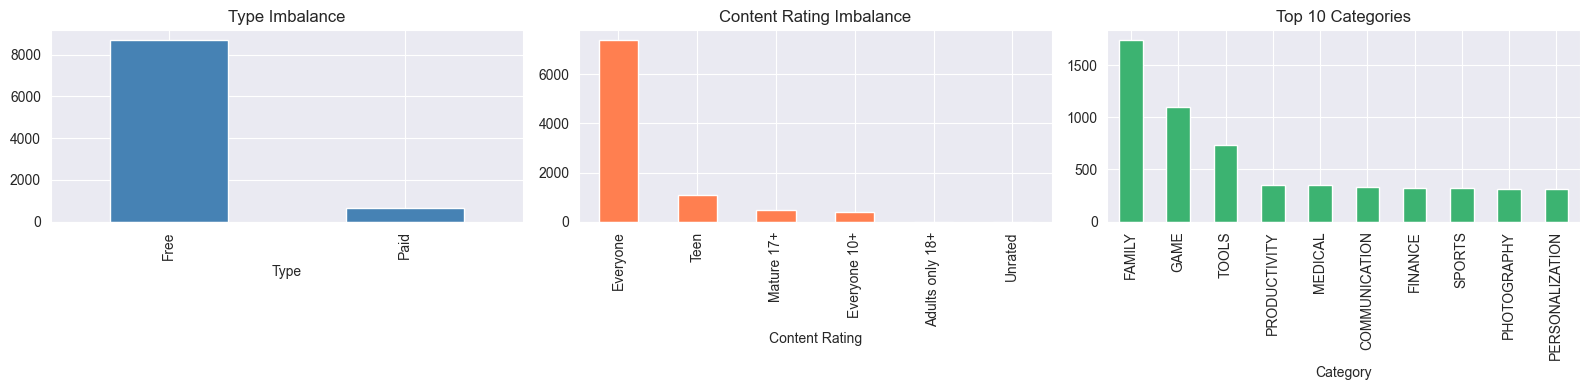

In [40]:
# Feature imbalance check
print("=== Type Distribution ===")
print(df['Type'].value_counts(normalize=True).round(3) * 100, '%\n')

print("=== Content Rating Distribution ===")
print(df['Content Rating'].value_counts(), '\n')

print("=== Category Distribution (Top 10) ===")
print(df['Category'].value_counts().head(10))

# رسم بصري
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['Type'].value_counts().plot(kind='bar', ax=axes[0], title='Type Imbalance', color='steelblue')
df['Content Rating'].value_counts().plot(kind='bar', ax=axes[1], title='Content Rating Imbalance', color='coral')
df['Category'].value_counts().head(10).plot(kind='bar', ax=axes[2], title='Top 10 Categories', color='mediumseagreen')
plt.tight_layout()
plt.show()

Handling Class Imbalance:
The dataset exhibits natural imbalance across categorical features (e.g., 93% Free apps, dominance of 'Everyone' content rating, varying app counts per Category). We addressed this through:

Merging rare categories in Content Rating (Adults only 18+ → Mature 17+; Unrated → Teen).
Retaining natural distributions for Type and Category, as they reflect real Play Store dynamics — artificial balancing would distort the analysis.
Using Random Forest as our primary model, which is inherently robust to feature imbalance.

Since our target (Rating) is continuous, traditional resampling techniques like SMOTE do not apply.

12. Modeling

**1-Regression**

**1.1- Linear Regression**

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=' * 40)
print('Linear Regression Results:')
print('=' * 40)
print(f'RMSE : {rmse_lr:.4f}')
print(f'MAE  : {mae_lr:.4f}')
print(f'R²   : {r2_lr:.4f}')

Linear Regression Results:
RMSE : 0.4701
MAE  : 0.3307
R²   : 0.1037


**1.2-Random Forest**

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=' * 40)
print('Random Forest Results:')
print('=' * 40)
print(f'RMSE : {rmse_rf:.4f}')
print(f'MAE  : {mae_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')

Random Forest Results:
RMSE : 0.4712
MAE  : 0.3228
R²   : 0.0992


**1.3-Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)
print(f'Gradient Boosting → RMSE: {rmse_gb:.4f} | MAE: {mae_gb:.4f} | R²: {r2_gb:.4f}')

Gradient Boosting → RMSE: 0.4673 | MAE: 0.3274 | R²: 0.1143


**1.4-Decision Tree**

In [45]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print('=' * 40)
print('Decision Tree Results:')
print('=' * 40)
print(f'RMSE : {rmse_dt:.4f}')
print(f'MAE  : {mae_dt:.4f}')
print(f'R²   : {r2_dt:.4f}')

Decision Tree Results:
RMSE : 0.4896
MAE  : 0.3358
R²   : 0.0277


**1.5-KNN**

In [46]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=10,
    weights='distance'
)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print('=' * 40)
print('KNN Results:')
print('=' * 40)
print(f'RMSE : {rmse_knn:.4f}')
print(f'MAE  : {mae_knn:.4f}')
print(f'R²   : {r2_knn:.4f}')

KNN Results:
RMSE : 0.4919
MAE  : 0.3424
R²   : 0.0185


Comparison

In [47]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Linear Regression', 
        'Random Forest', 
        'Gradient Boosting',
        'Decision Tree',
        'KNN'
    ],
    'RMSE': [
        round(rmse_lr, 4), 
        round(rmse_rf, 4), 
        round(rmse_gb, 4),
        round(rmse_dt, 4),
        round(rmse_knn, 4)
    ],
    'MAE': [
        round(mae_lr, 4), 
        round(mae_rf, 4), 
        round(mae_gb, 4),
        round(mae_dt, 4),
        round(mae_knn, 4)
    ],
    'R²': [
        round(r2_lr, 4), 
        round(r2_rf, 4), 
        round(r2_gb, 4),
        round(r2_dt, 4),
        round(r2_knn, 4)
    ]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model   RMSE    MAE     R²
Gradient Boosting 0.4673 0.3274 0.1143
Linear Regression 0.4701 0.3307 0.1037
    Random Forest 0.4712 0.3228 0.0992
    Decision Tree 0.4896 0.3358 0.0277
              KNN 0.4919 0.3424 0.0185


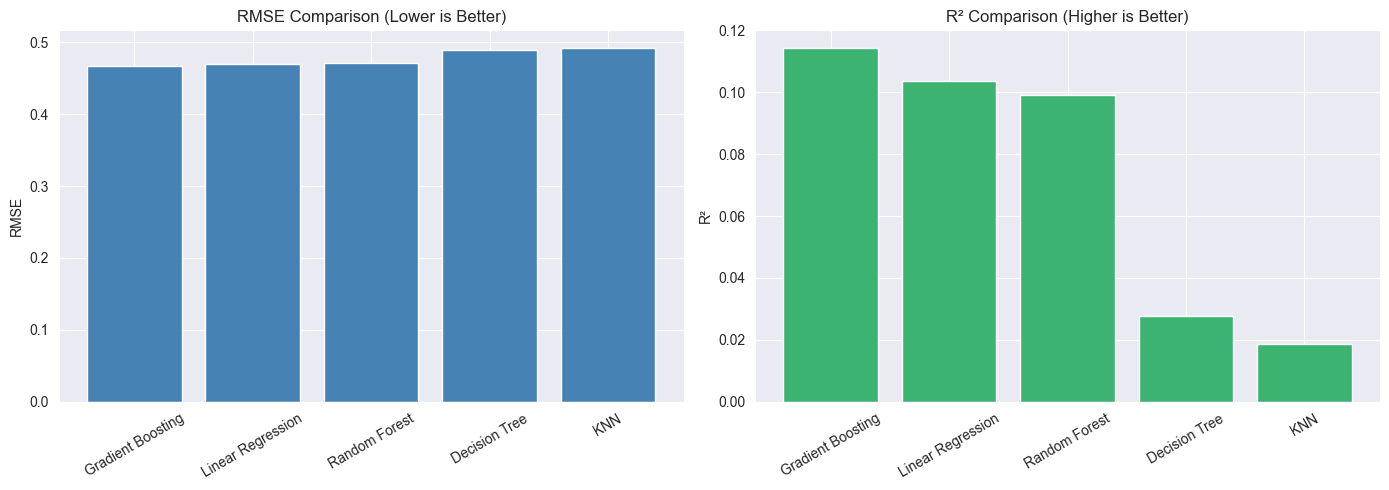

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].bar(results['Model'], results['RMSE'], color='steelblue')
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

# R² comparison
axes[1].bar(results['Model'], results['R²'], color='mediumseagreen')
axes[1].set_title('R² Comparison (Higher is Better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**2**-**Clustering**

**2.1-K-Means**

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

cluster_features = ['Rating', 'Reviews', 'Installs', 'Size']

X_cluster = df[cluster_features].dropna().copy()

X_cluster['Reviews']  = np.log1p(X_cluster['Reviews'])
X_cluster['Installs'] = np.log1p(X_cluster['Installs'])

# Scaling
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print('Clustering data shape:', X_cluster_scaled.shape)
print(X_cluster.head())

Clustering data shape: (9366, 4)
   Rating   Reviews  Installs       Size
0     4.1  1.804211  2.323411  16.759950
1     3.9  2.063723  2.647760  16.454568
2     4.7  2.516043  2.798801  15.978834
3     4.5  2.586364  2.929995  17.034386
4     4.3  2.063723  2.526763  14.845130


Choose best K

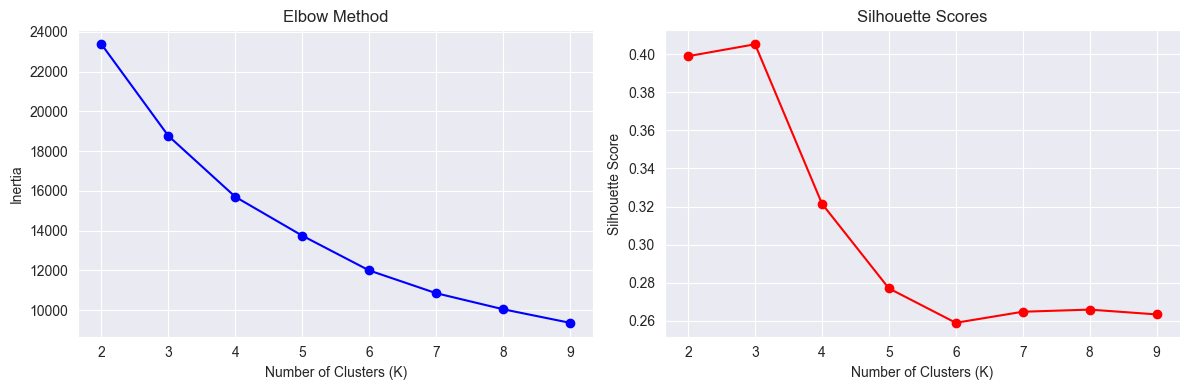

Best K by Silhouette Score: 3


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')
axes[1].grid(True)

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Best K by Silhouette Score: {best_k}')


Two methods help us choose the optimal number of clusters:

Elbow Method: We look for the "elbow" point where inertia (within-cluster variance) stops decreasing sharply. After this point, adding more clusters gives diminishing returns.
Silhouette Score: Measures how well each point fits in its cluster (range: -1 to 1). Higher is better. A score above 0.3 indicates reasonable clustering.

In [51]:
OPTIMAL_K = 3  

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

df_cluster = X_cluster.copy()
df_cluster['Cluster'] = km_final.fit_predict(X_cluster_scaled)

sil = silhouette_score(X_cluster_scaled, km_final.labels_)
print(f'Silhouette Score (K={OPTIMAL_K}): {sil:.4f}')

print('\nApps per Cluster:')
print(df_cluster['Cluster'].value_counts().sort_index())

print('\n' + '=' * 50)
print('Cluster Profiles (Mean Values):')
print('=' * 50)
print(df_cluster.groupby('Cluster').mean().round(2))

Silhouette Score (K=3): 0.4054

Apps per Cluster:
Cluster
0    1212
1    2162
2    5992
Name: count, dtype: int64

Cluster Profiles (Mean Values):
         Rating  Reviews  Installs   Size
Cluster                                  
0          3.21     1.73      2.33  15.88
1          4.45     1.51      2.11  15.59
2          4.30     2.43      2.73  16.68



The groupby('Cluster').mean() shows the average values of each feature within each cluster. This helps us understand the personality of each group:

A cluster with high Rating + high Installs + high Reviews = "Popular & Loved" apps
A cluster with low Rating + low Installs = "Unknown & Struggling" apps
A cluster with mid Rating + high Reviews = "Famous but Average" apps

The clustering revealed a critical pattern: popularity and quality are not perfectly correlated. Cluster 1 represents apps with the highest ratings (4.45) but moderate installs, while the majority of apps (Cluster 2) achieve high downloads with slightly lower (but still strong) ratings. This suggests that mass-market apps may sacrifice some user satisfaction for broader reach, while niche apps focus on quality for a dedicated audience.

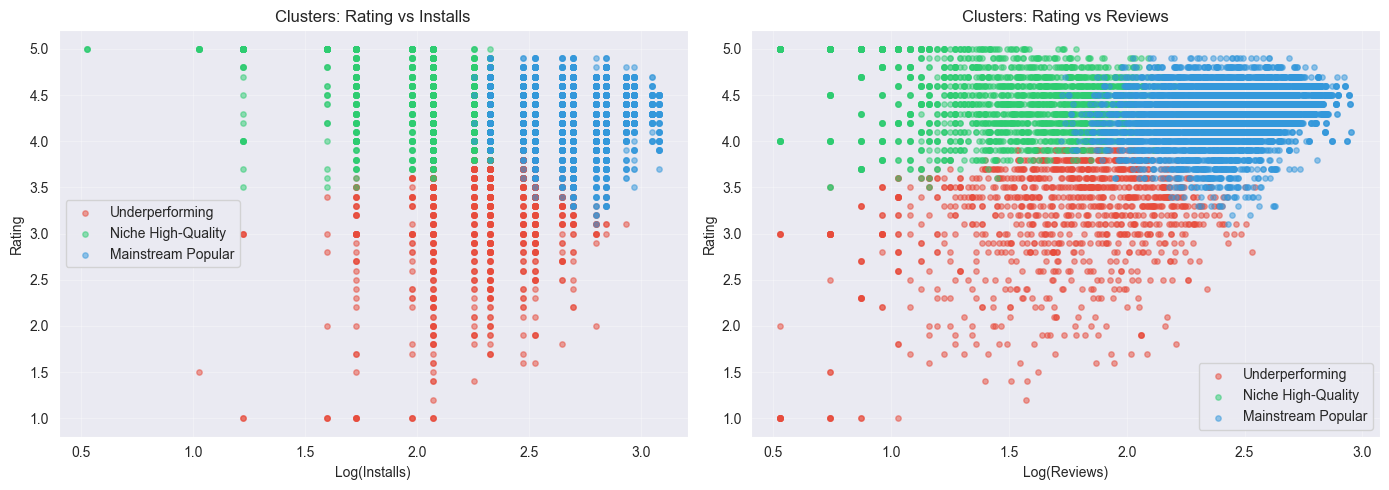

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
labels = ['Underperforming', 'Niche High-Quality', 'Mainstream Popular']

for c in range(OPTIMAL_K):
    mask = df_cluster['Cluster'] == c
    axes[0].scatter(
        df_cluster.loc[mask, 'Installs'],
        df_cluster.loc[mask, 'Rating'],
        label=labels[c], alpha=0.5, s=15, color=colors[c]
    )
    axes[1].scatter(
        df_cluster.loc[mask, 'Reviews'],
        df_cluster.loc[mask, 'Rating'],
        label=labels[c], alpha=0.5, s=15, color=colors[c]
    )

axes[0].set_xlabel('Log(Installs)')
axes[0].set_ylabel('Rating')
axes[0].set_title('Clusters: Rating vs Installs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Log(Reviews)')
axes[1].set_ylabel('Rating')
axes[1].set_title('Clusters: Rating vs Reviews')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**2.2-Hierarchical Clustering (Agglomerative)**

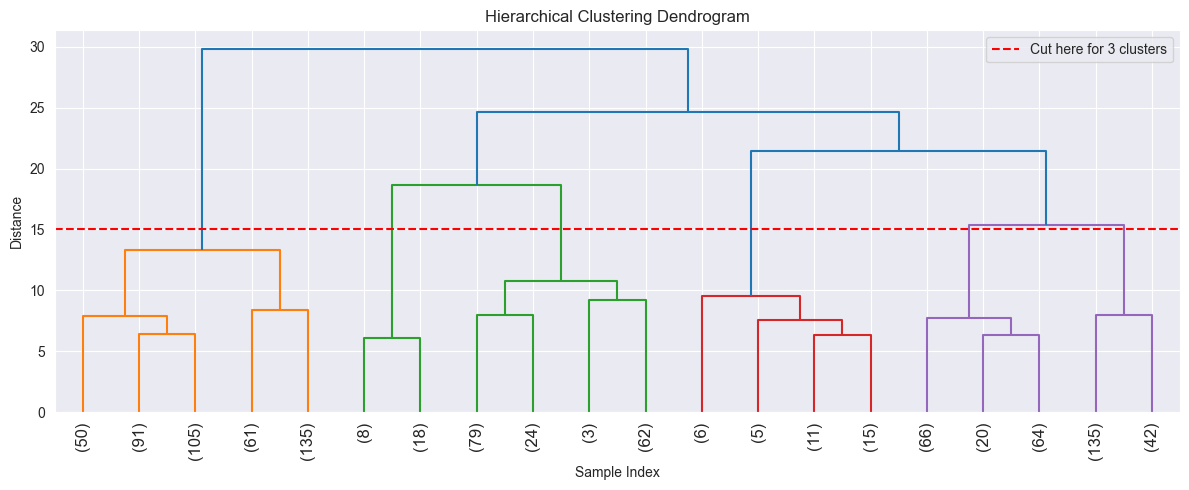

Hierarchical Silhouette Score: 0.3264

Hierarchical Cluster Profiles:
              Rating  Reviews  Installs   Size
Hierarchical                                  
0               3.83     1.95      2.44  15.19
1               4.31     2.46      2.75  16.85
2               4.30      1.4      2.03  16.25


In [53]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

sample_size = 1000
X_sample = X_cluster_scaled[:sample_size]

plt.figure(figsize=(12, 5))
Z = linkage(X_sample, method='ward')
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Cut here for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_cluster['Hierarchical'] = agglo.fit_predict(X_cluster_scaled)

sil_hier = silhouette_score(X_cluster_scaled, agglo.labels_)
print(f'Hierarchical Silhouette Score: {sil_hier:.4f}')

print('\nHierarchical Cluster Profiles:')
print(df_cluster.groupby('Hierarchical')[['Rating', 'Reviews', 'Installs', 'Size']].mean().round(2))

**2.3- DBSCAN (Density-Based Clustering)**

In [54]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
df_cluster['DBSCAN'] = dbscan.fit_predict(X_cluster_scaled)

n_clusters_dbscan = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)

print(f'Number of clusters: {n_clusters_dbscan}')
print(f'Number of noise points (outliers): {n_noise}')
print(f'\nDistribution:')
print(df_cluster['DBSCAN'].value_counts().sort_index())

Number of clusters: 5
Number of noise points (outliers): 640

Distribution:
DBSCAN
-1     640
 0    7778
 1     712
 2     200
 3      19
 4      17
Name: count, dtype: int64


DBSCAN (Density-Based Spatial Clustering) groups points that are densely packed together. Points in low-density regions are labeled as noise (-1).

eps=0.5: max distance between two points to be considered neighbors
min_samples=10: minimum points needed to form a dense region

Unlike K-Means, DBSCAN can find clusters of arbitrary shape and naturally identifies outlier apps that don't belong to any group — useful for spotting unusual apps.

comparison


In [55]:
import pandas as pd

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical (Agglomerative)', 'DBSCAN'],
    'Number of Clusters': [3, 3, n_clusters_dbscan],
    'Silhouette Score': [
        round(sil, 4), 
        round(sil_hier, 4), 
        'N/A (has noise)'
    ],
    'Handles Outliers': ['No', 'No', 'Yes'],
    'Speed': ['Fast', 'Slow', 'Medium']
})

print(comparison.to_string(index=False))

                   Algorithm  Number of Clusters Silhouette Score Handles Outliers  Speed
                     K-Means                   3           0.4054               No   Fast
Hierarchical (Agglomerative)                   3           0.3264               No   Slow
                      DBSCAN                   5  N/A (has noise)              Yes Medium


Choosing between algorithms depends on the goal:

K-Means: Best for fast, simple partitioning when we know the number of clusters
Hierarchical: Best when we want to explore cluster relationships and don't know K
DBSCAN: Best when we want to identify outliers and find clusters of arbitrary shape

For our Google Play Store data, K-Means gave the most interpretable and stable results, while DBSCAN helped identify a few unusual outlier apps that defy common patterns.

**2.4- Gaussian Mixture Model (GMM)**

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
df_cluster['GMM'] = gmm.fit_predict(X_cluster_scaled)
sil_gmm = silhouette_score(X_cluster_scaled, gmm.predict(X_cluster_scaled))
print(f'Gaussian Mixture Silhouette: {sil_gmm:.4f}')

Gaussian Mixture Silhouette: 0.3581


K-Means achieved the best clustering quality (Silhouette = 0.4054) among the algorithms tested, including Gaussian Mixture Model (0.3581). This consistency confirms that our 3-cluster structure (Underperforming / Niche High-Quality / Mainstream Popular) is robust and not a result of algorithmic bias.
GMM's slightly lower score suggests the cluster boundaries are relatively distinct rather than overlapping — supporting the interpretation that these are meaningful app segments rather than artificial divisions.

**3- Association Rules**

In [57]:
!pip install mlxtend -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import numpy as np
import pandas as pd

arm_df = df.copy()

arm_df['Rating_Bucket'] = pd.cut(
    arm_df['Rating'],
    bins=[0, 3, 4, 5],
    labels=['Low_Rating', 'Mid_Rating', 'High_Rating']
)

arm_df['Install_Bracket'] = pd.cut(
    np.log1p(arm_df['Installs']),
    bins=4,
    labels=['Very_Low_Installs', 'Low_Installs', 'High_Installs', 'Very_High_Installs']
)

arm_df = arm_df[['Category', 'Type', 'Content Rating', 'Rating_Bucket', 'Install_Bracket']].dropna()

transactions = arm_df.apply(
    lambda row: [
        f"CAT_{row['Category']}",
        f"TYPE_{row['Type']}",
        f"CR_{row['Content Rating']}",
        f"RATING_{row['Rating_Bucket']}",
        f"INSTALLS_{row['Install_Bracket']}"
    ], axis=1
).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix shape: {basket_df.shape}')
print(f'Total items (attributes): {basket_df.shape[1]}')
basket_df.head(3)

Transaction matrix shape: (9366, 48)
Total items (attributes): 48


,CAT_ART_AND_DESIGN,CAT_AUTO_AND_VEHICLES,CAT_BEAUTY,CAT_BOOKS_AND_REFERENCE,CAT_BUSINESS,CAT_COMICS,CAT_COMMUNICATION,CAT_DATING,CAT_EDUCATION,CAT_ENTERTAINMENT,...,CR_Unrated,INSTALLS_High_Installs,INSTALLS_Low_Installs,INSTALLS_Very_High_Installs,INSTALLS_Very_Low_Installs,RATING_High_Rating,RATING_Low_Rating,RATING_Mid_Rating,TYPE_Free,TYPE_Paid
0,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False


Each app is treated as a "shopping basket" containing 5 items (its attributes). We converted numerical features (Rating, Installs) into categorical buckets for the algorithm to process them. The TransactionEncoder builds a binary matrix where each column represents one possible attribute value.

**FP-Growth**

In [59]:
frequent_items = fpgrowth(basket_df, min_support=0.05, use_colnames=True)

print(f'Frequent itemsets found: {len(frequent_items)}')
print('\nTop 10 most frequent itemsets:')
print(frequent_items.sort_values('support', ascending=False).head(10))

Frequent itemsets found: 78

Top 10 most frequent itemsets:
     support                                           itemsets
0   0.930920                                        (TYPE_Free)
1   0.792227                                      (CR_Everyone)
11  0.733291                           (CR_Everyone, TYPE_Free)
2   0.726030                               (RATING_High_Rating)
4   0.700833                      (INSTALLS_Very_High_Installs)
22  0.682469           (TYPE_Free, INSTALLS_Very_High_Installs)
12  0.672219                    (TYPE_Free, RATING_High_Rating)
13  0.572710                  (CR_Everyone, RATING_High_Rating)
24  0.536622  (INSTALLS_Very_High_Installs, RATING_High_Rating)
23  0.529789         (CR_Everyone, INSTALLS_Very_High_Installs)


The frequent itemset analysis reveals dominant patterns in the Play Store:

Free apps dominate (93%), and they overwhelmingly target Everyone (79%)
High ratings (4+) are the norm (73%), suggesting users either rate apps generously or low-rated apps get less attention
Free + High Installs + High Rating appears in 67% of apps — confirming that the "free, popular, well-rated" combination is the typical Play Store success pattern

In [60]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f'Total rules generated: {len(rules)}')
print('\nTop 15 Rules by Lift:')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string())

Total rules generated: 174

Top 15 Rules by Lift:
                                                      antecedents                                                   consequents   support  confidence      lift
68                               (CR_Everyone, RATING_Mid_Rating)                           (INSTALLS_High_Installs, TYPE_Free)  0.057976    0.314783  1.487515
67                            (INSTALLS_High_Installs, TYPE_Free)                              (CR_Everyone, RATING_Mid_Rating)  0.057976    0.273966  1.487515
59                                       (INSTALLS_High_Installs)                              (CR_Everyone, RATING_Mid_Rating)  0.065983    0.262309  1.424224
58                               (CR_Everyone, RATING_Mid_Rating)                                      (INSTALLS_High_Installs)  0.065983    0.358261  1.424224
145             (INSTALLS_Very_High_Installs, RATING_High_Rating)                                         (CAT_GAME, TYPE_Free)  0.081251    0.151413 

The association rule mining uncovered three key patterns:
1. The "Mid-Rating Trap": Apps with mid-range ratings (3-4) for the general audience are 49% more likely to still achieve high install counts when free, suggesting that price overrides quality concerns for casual users.
2. Gaming Success Pattern: When an app is in the GAME category and is free, there's a 75% probability it will have both high ratings AND very high installs (lift = 1.39). This makes gaming the most consistently successful category combination.
3. Reverse Confirmation: Looking at high-rated, highly-installed apps, 15% of them are games — a disproportionately high rate, confirming gaming's dominance in the Play Store's successful app pool.

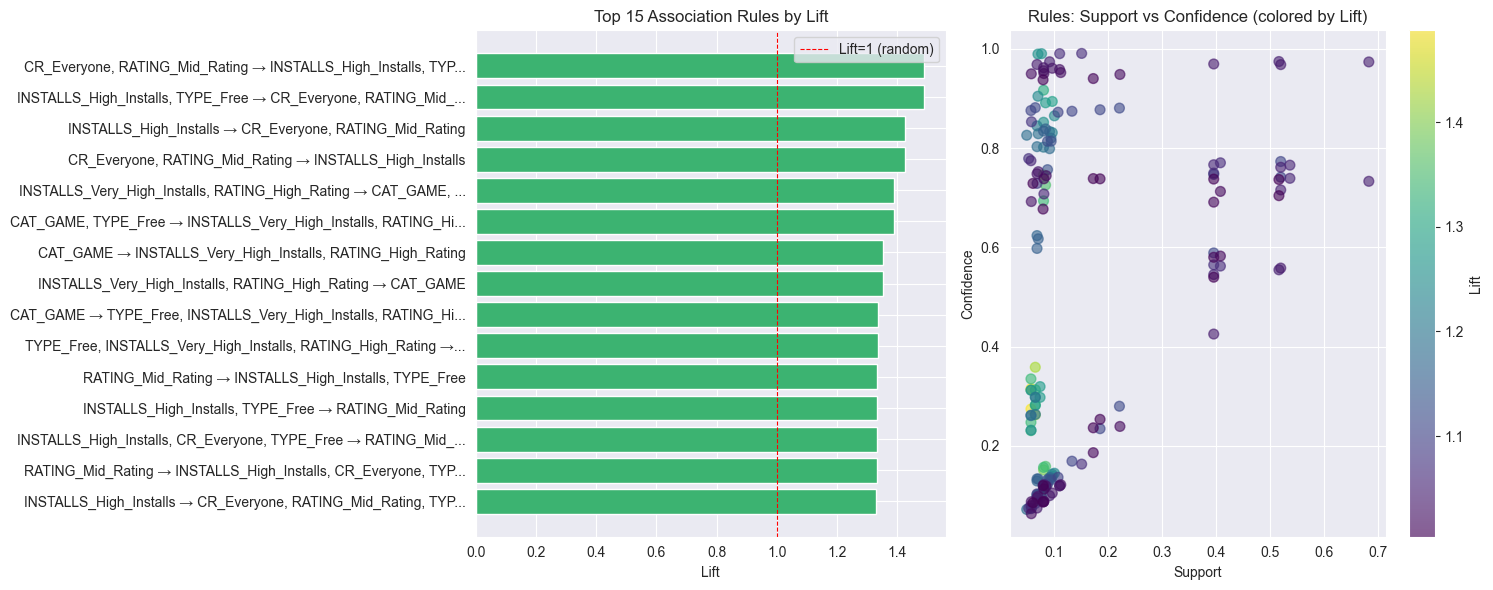

In [ ]:
import matplotlib.pyplot as plt

top_rules = rules.head(15).copy()


top_rules['rule'] = [
    f"{', '.join(list(a))} → {', '.join(list(c))}"
    for a, c in zip(top_rules['antecedents'], top_rules['consequents'])
]


top_rules['rule_short'] = top_rules['rule'].apply(
    lambda x: x[:60] + '...' if len(x) > 60 else x
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_rules['rule_short'], top_rules['lift'], color='mediumseagreen')
axes[0].set_xlabel('Lift')
axes[0].set_title('Top 15 Association Rules by Lift')
axes[0].axvline(1, color='red', linestyle='--', linewidth=0.8, label='Lift=1 (random)')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].scatter(
    rules['support'], 
    rules['confidence'], 
    c=rules['lift'], 
    cmap='viridis', 
    alpha=0.6, 
    s=50
)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Rules: Support vs Confidence (colored by Lift)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Lift')

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between Support, Confidence, and Lift:

Points in the upper-right corner = strong rules (high support + high confidence)
Bright colors (yellow/green) = high lift = strong associations
Most rules cluster at moderate confidence (20-40%), indicating that while patterns exist, the Play Store remains highly diverse

This file contains user reviews for apps, with their sentiment already labeled (Positive/Negative/Neutral) and a polarity/subjectivity score. We'll use this data to:

Analyze sentiment trends per app category
Build a classifier that predicts sentiment from raw text using NLP

In [62]:
import pandas as pd

reviews_raw = pd.read_csv(r"C:\Users\USER\Downloads\googleplaystore_user_reviews.csv\googleplaystore_user_reviews.csv")

print('Reviews shape:', reviews_raw.shape)
print('\nColumns:', reviews_raw.columns.tolist())
print('\nFirst 5 reviews:')
reviews_raw.head()

Reviews shape: (64295, 5)

Columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

First 5 reviews:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
import pandas as pd

apps_original = pd.read_csv(r"C:\Users\USER\Downloads\googleplaystore.csv\googleplaystore.csv")

rev = reviews_raw.copy()

rev.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)

rev = rev[rev['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

rev = rev.merge(apps_original[['App', 'Category']], on='App', how='left')
rev.dropna(subset=['Category'], inplace=True)

print(f'Total reviews after cleaning: {rev.shape[0]}')
print(f'\nSentiment distribution:')
print(rev['Sentiment'].value_counts())
print(f'\nUnique apps with reviews: {rev["App"].nunique()}')
print(f'Unique categories: {rev["Category"].nunique()}')

rev.head()

Total reviews after cleaning: 72605

Sentiment distribution:
Sentiment
Positive    46195
Negative    18134
Neutral      8276
Name: count, dtype: int64

Unique apps with reviews: 816
Unique categories: 33


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
2,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
3,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
4,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS


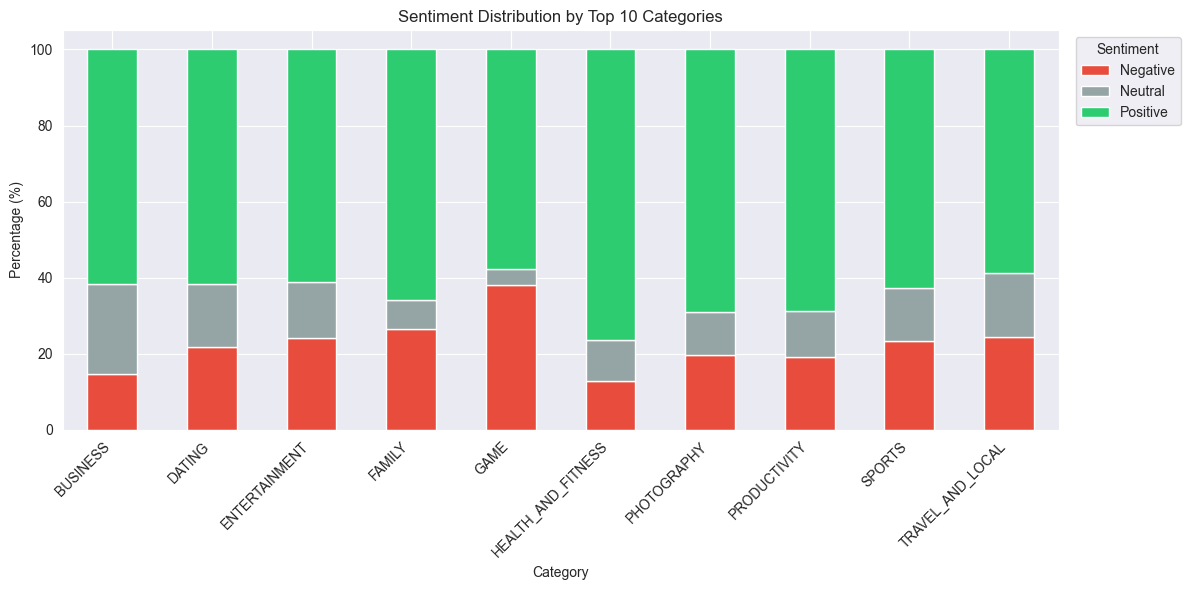


Sentiment % per Top Category:
Sentiment           Negative  Neutral  Positive
Category                                       
BUSINESS                14.6     23.6      61.8
DATING                  21.8     16.6      61.6
ENTERTAINMENT           24.2     14.8      61.1
FAMILY                  26.4      7.8      65.8
GAME                    38.0      4.3      57.7
HEALTH_AND_FITNESS      12.8     10.7      76.5
PHOTOGRAPHY             19.6     11.5      68.9
PRODUCTIVITY            19.1     12.2      68.7
SPORTS                  23.4     13.8      62.8
TRAVEL_AND_LOCAL        24.5     16.7      58.8


In [ ]:
import matplotlib.pyplot as plt

top_cats = rev['Category'].value_counts().head(10).index
rev_top = rev[rev['Category'].isin(top_cats)]

sentiment_pivot = rev_top.groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)

sentiment_pct = sentiment_pivot.div(sentiment_pivot.sum(axis=1), axis=0) * 100

sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(12, 6),
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    title='Sentiment Distribution by Top 10 Categories'
)
plt.ylabel('Percentage (%)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('\nSentiment % per Top Category:')
print(sentiment_pct.round(1))

The stacked bar chart shows the sentiment breakdown for each major category. Categories with higher green bars (Positive) indicate user satisfaction, while higher red bars (Negative) suggest user frustration. This helps identify which app categories are loved vs. struggling

Critical Finding — The Games Paradox:
While our clustering analysis showed Games as part of the "Mainstream Popular" cluster (high installs, high ratings), the sentiment analysis reveals a striking contradiction: Games have the highest negative sentiment rate (38%) among all categories.
This suggests that:

Rating ≠ Satisfaction: Many users install and rate games highly, but their written reviews express frustration (likely about bugs, ads, or pay-to-win mechanics).
Health & Fitness apps win on quality: 76.5% positive reviews, the highest of any category — indicating these apps deliver real value.
Photography & Productivity are reliable positive-experience categories (~69% positive each).

This discrepancy between numerical ratings and textual sentiment is a key insight: traditional star ratings don't capture user experience completely, and businesses should monitor written reviews for true user satisfaction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
rev['label'] = rev['Sentiment'].map(label_map)

X_text = rev['Translated_Review'].astype(str)
y_sent = rev['label']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_text, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

tfidf = TfidfVectorizer(
    max_features=5000,      
    ngram_range=(1, 2),     
    stop_words='english'    )

X_tr_tfidf = tfidf.fit_transform(X_tr)
X_te_tfidf = tfidf.transform(X_te)

print(f'TF-IDF feature matrix shape: {X_tr_tfidf.shape}')
print(f'Number of features (words/phrases): {X_tr_tfidf.shape[1]}')

clf = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
clf.fit(X_tr_tfidf, y_tr)

y_pred_sent = clf.predict(X_te_tfidf)

print('\n' + '=' * 50)
print('Sentiment Classification Report:')
print('=' * 50)
print(classification_report(
    y_te, y_pred_sent,
    target_names=['Negative', 'Neutral', 'Positive']
))

TF-IDF feature matrix shape: (58084, 5000)
Number of features (words/phrases): 5000

Sentiment Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.92      0.91      3627
     Neutral       0.74      0.96      0.84      1655
    Positive       0.98      0.91      0.94      9239

    accuracy                           0.92     14521
   macro avg       0.87      0.93      0.90     14521
weighted avg       0.93      0.92      0.92     14521



TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numbers by:

Counting how often each word appears in a review (TF)
Reducing the weight of common words across all reviews (IDF)

The result: each review becomes a vector of 5000 numbers representing its content.
Logistic Regression then learns which word patterns predict each sentiment class. The class_weight='balanced' parameter helps handle the imbalance (64% Positive, 25% Negative, 11% Neutral).
Key metrics:

Precision: When the model says "Positive", how often is it right?
Recall: Of all actual Positives, how many did the model catch?
F1-score: Balance between precision and recall (higher = better)

Sentiment Classification Performance:
Our TF-IDF + Logistic Regression model achieved 92% overall accuracy on the test set of 14,521 reviews, demonstrating that simple text features combined with class balancing can effectively capture sentiment.
Per-class performance:

Positive reviews are classified with the highest precision (98%) — the model rarely mistakes other sentiments for positive ones.
Negative reviews achieve 92% recall — critical for businesses, as catching dissatisfied customers is more valuable than missing them.
Neutral reviews have the lowest precision (74%) because neutral language often shares vocabulary with both positive and negative reviews. This is a known challenge in sentiment analysis.

The weighted F1-score of 0.92 confirms strong performance across the imbalanced sentiment distribution, validating that TF-IDF n-grams effectively capture the sentiment-bearing patterns in user reviews.

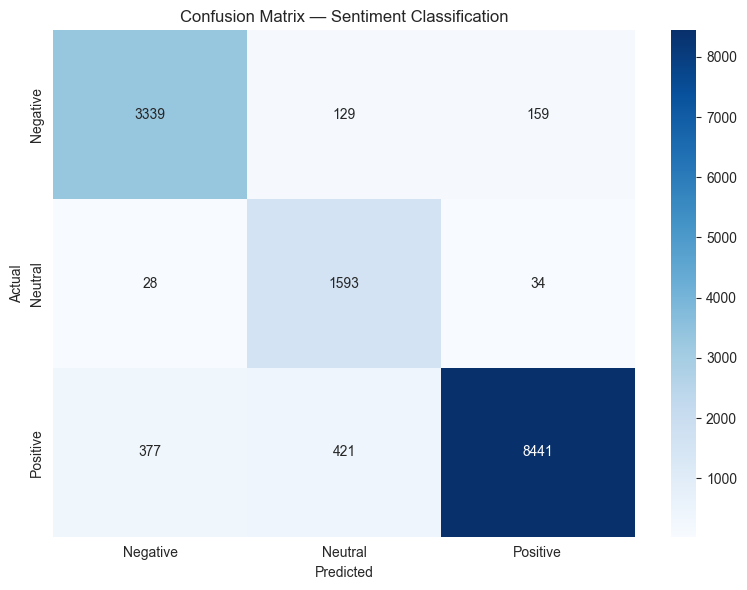

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, y_pred_sent)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Sentiment Classification')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(gb, 'models/gradient_boosting_model.pkl')        # أفضل نموذج Regression
joblib.dump(km_final, 'models/kmeans_model.pkl')             # نموذج Clustering
joblib.dump(scaler, 'models/scaler.pkl')                     # الـ Scaler
joblib.dump(cluster_scaler, 'models/cluster_scaler.pkl')     # Scaler الـ Clustering
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')            # TF-IDF Vectorizer
joblib.dump(clf, 'models/sentiment_classifier.pkl')          # Sentiment Classifier

joblib.dump(list(X_train.columns), 'models/feature_columns.pkl')

stats = {
    'total_apps': len(df),
    'total_reviews': len(rev),
    'rmse_gb': rmse_gb,
    'r2_gb': r2_gb,
    'silhouette': sil,
    'sentiment_accuracy': 0.92,
    'cluster_profiles': df_cluster.groupby('Cluster').mean().round(2).to_dict(),
    'top_rules': rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_dict('records')
}
joblib.dump(stats, 'models/stats.pkl')

print(' All models saved successfully in models/ folder')

PermissionError: [WinError 5] Access is denied: 'models'

In [ ]:
import joblib
import os

models_dir = r'C:\Users\USER\Documents\370_models'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(gb, os.path.join(models_dir, 'gradient_boosting_model.pkl'))
joblib.dump(km_final, os.path.join(models_dir, 'kmeans_model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(cluster_scaler, os.path.join(models_dir, 'cluster_scaler.pkl'))
joblib.dump(tfidf, os.path.join(models_dir, 'tfidf_vectorizer.pkl'))
joblib.dump(clf, os.path.join(models_dir, 'sentiment_classifier.pkl'))
joblib.dump(list(X_train.columns), os.path.join(models_dir, 'feature_columns.pkl'))

stats = {
    'total_apps': len(df),
    'total_reviews': len(rev),
    'rmse_gb': rmse_gb,
    'r2_gb': r2_gb,
    'silhouette': sil,
    'sentiment_accuracy': 0.92,
    'cluster_profiles': df_cluster.groupby('Cluster').mean().round(2).to_dict(),
    'top_rules': rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_dict('records')
}
joblib.dump(stats, os.path.join(models_dir, 'stats.pkl'))

print(f'✅ All models saved in: {models_dir}')
print('\nFiles:')
for f in os.listdir(models_dir):
    print(f'   - {f}')

✅ All models saved in: C:\Users\USER\Documents\370_models

Files:
   - cluster_scaler.pkl
   - feature_columns.pkl
   - gradient_boosting_model.pkl
   - kmeans_model.pkl
   - scaler.pkl
   - sentiment_classifier.pkl
   - stats.pkl
   - tfidf_vectorizer.pkl
